# EDA — Credit Card Fraud Detection

Run `python src/data.py` first to generate `data/processed/*.csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

train_df = pd.read_csv("../data/processed/train.csv")
train_df.shape

(199364, 34)

In [9]:
train_df.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V24,V25,V26,V27,V28,Amount,Class,hour_of_day,day,Amount_log
1942,101161.0,-1.250133,2.240125,-0.707468,-0.350870,-0.122623,0.490910,-1.950663,-7.430332,1.866763,...,-0.248112,0.644179,0.256578,0.275955,0.174912,1.98,0,4.0,1,1.091923
71016,49348.0,1.109816,-0.675091,0.198769,0.642489,1.136811,4.765364,-1.581113,1.315838,1.573243,...,1.046270,0.709888,-0.211403,0.107810,0.035199,27.52,0,13.0,0,3.350606
3834,45319.0,-1.053696,0.844079,2.394763,-0.121864,-0.341535,-0.375662,0.322540,0.136595,-0.527082,...,0.552543,0.087716,0.220611,0.148132,0.140895,29.54,0,12.0,0,3.419037
150227,79600.0,-1.655086,-0.422348,2.588347,-0.696614,0.455651,-0.851525,-0.136742,0.340445,0.152145,...,0.553251,0.600338,0.239593,-0.057975,0.059653,29.99,0,22.0,0,3.433665
36912,147795.0,-1.968094,0.199864,1.053338,-0.223421,0.931466,-1.167480,1.010529,-0.380079,-0.218007,...,0.060244,0.587484,0.359874,-0.636013,-0.572921,1.98,0,17.0,1,1.091923


## Class balance

The whole point of this project: fraud is ~0.17% of transactions.

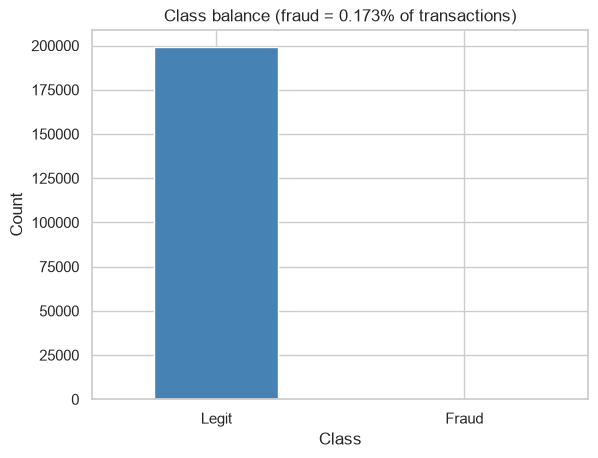

In [2]:
class_counts = train_df["Class"].value_counts()
fraud_pct = class_counts[1] / class_counts.sum() * 100

ax = class_counts.plot(kind="bar", color=["steelblue", "crimson"])
ax.set_xticklabels(["Legit", "Fraud"], rotation=0)
ax.set_title(f"Class balance (fraud = {fraud_pct:.3f}% of transactions)")
ax.set_ylabel("Count")
plt.show()

## Transaction amount by class

Most transactions are small. Only a few are extremely large. A histogram would look like Almost everything gets squashed on the left. You cannot see the actual pattern. So using Log scale since amounts are heavily right-skewed.

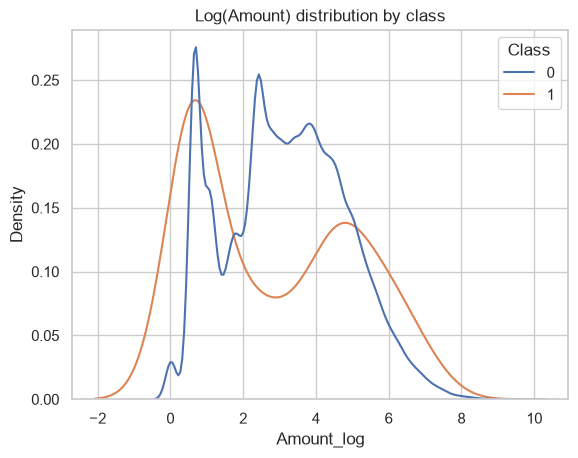

In [3]:
fig, ax = plt.subplots()
sns.kdeplot(data=train_df, x="Amount_log", hue="Class", common_norm=False, ax=ax)
ax.set_title("Log(Amount) distribution by class")
plt.show()

## Fraud count by hour of day

Same chart the dashboard's "Time & volume" card will show, computed here first.

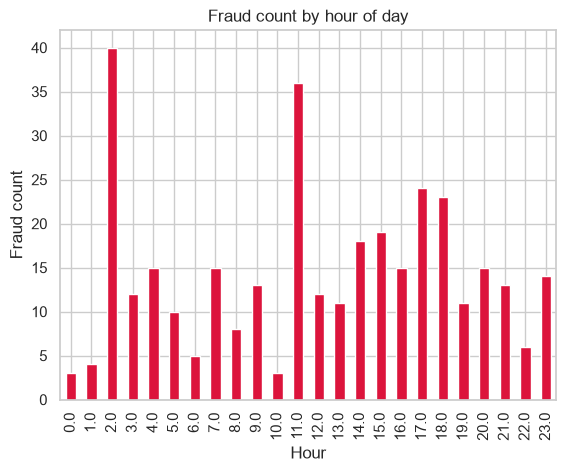

In [4]:
fraud_by_hour = train_df[train_df["Class"] == 1].groupby("hour_of_day").size()

ax = fraud_by_hour.plot(kind="bar", color="crimson")
ax.set_title("Fraud count by hour of day")
ax.set_xlabel("Hour")
ax.set_ylabel("Fraud count")
plt.show()

## Feature correlation with Class

Which of the PCA components (V1–V28) correlate most with fraud.

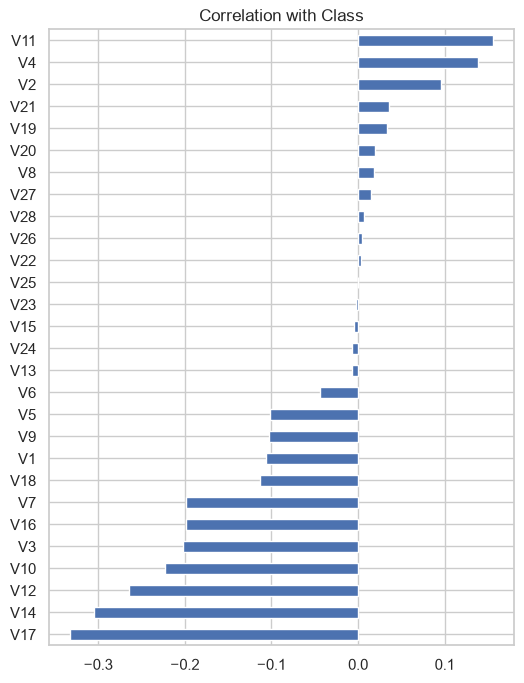

In [5]:
v_cols = [c for c in train_df.columns if c.startswith("V")]
corr_with_class = train_df[v_cols + ["Class"]].corr()["Class"].drop("Class")
corr_with_class = corr_with_class.sort_values()

fig, ax = plt.subplots(figsize=(6, 8))
corr_with_class.plot(kind="barh", ax=ax)
ax.set_title("Correlation with Class")
plt.show()